In [1]:
!pip install google-genai

In [2]:
from google import genai

client = genai.Client(api_key="###################")

model="gemini-3-flash-preview"
prompt="Explain quantum computing in one sentence."

# Generate content
response = client.models.generate_content(
    model= model,
    contents=prompt
)

print(response.text)

Quantum computing uses the principles of quantum mechanics to process information in multiple states simultaneously, enabling it to solve complex problems far beyond the reach of traditional supercomputers.


In [3]:
!pip install pandas scipy

import pandas as pd
from scipy.io import arff
import numpy as np
import os;

# Define the path to your ARFF file
file_path = os.path.join('/kaggle/input/datasets/tarekyahia/credit-g', 'dataset_31_credit-g.arff')

# 1. Load the ARFF data
df, meta = arff.loadarff(file_path)

# 2. Convert the structured array to a Pandas DataFrame
data = pd.DataFrame(df)

object_cols = data.select_dtypes(include=['object']).columns
for col in object_cols:
    # Use .apply() with a lambda function for robust decoding.
    # It checks if the value is a byte string (isinstance(x, bytes)) and decodes it using 'utf-8'.
    # Otherwise, it returns the value as is.
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [4]:
print(data.columns.tolist())

['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


In [5]:
metadata = {
  "features": {
    "checking_status": "Status of existing checking account, in Deutsche Mark.",
    "duration": "Duration in months",
    "credit_history": "Credit history (credits taken, paid back duly, delays, critical accounts)",
    "purpose": "Purpose of the credit (car, television,...)",
    "credit_amount": "Credit amount",
    "savings_status": "Status of savings account/bonds, in Deutsche Mark.",
    "employment": "Present employment, in number of years.",
    "installment_commitment": "Installment rate in percentage of disposable income",
    "personal_status": "Personal status (married, single,...) and sex",
    "other_debtors": "Other debtors / guarantors",
    "residence_since": "Present residence since X years",
    "property_magnitude": "Property (e.g. real estate)",
    "age": "Age in years",
    "other_payment_plans": "Other installment plans (banks, stores)",
    "housing": "Housing (rent, own,...)",
    "existing_credits": "Number of existing credits at this bank",
    "job": "Job",
    "num_dependents": "Number of people being liable to provide maintenance for",
    "own_telephone": "Telephone (yes,no)",
    "foreign_worker": "Foreign worker (yes,no)",
    "class": "Good or bad credit risk (cost matrix: FN penalty=5, FP penalty=1)"
  }
}


In [6]:
# 1. Credit amount per month
data['credit_per_month'] = data['credit_amount'] / data['duration']

#2. Credit amount per dependent
data['credit_per_dependent'] = data['credit_amount'] / (data['num_dependents'] + 1)

#3. Employment stability score
employment_mapping = {
    'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4
}

data['employment_stability_score'] = data['employment'].map(employment_mapping)

#4. Savings strength score
savings_mapping = {
    'no known savings': 0,
    '<100': 1,
    '100<=X<500': 2,
    '500<=X<1000': 3,
    '>=1000': 4
}

data['savings_strength_score'] = data['savings_status'].map(savings_mapping)

#5. Bad Credit History
bad_history_categories = ["critical/other existing credit", "delayed previously"]

data['bad_history'] = data['credit_history'].isin(bad_history_categories).astype(int)

#6. Job stability score
job_mapping = {
    'unemp/unskilled non res': 0,
    'unskilled resident': 1,
    'skilled': 2,
    'high qualif/self emp/mgmt': 3
}

data['job_stability_score'] = data['job'].map(job_mapping)

#7. Credit pressure ratio
#duration_installment_product = data['duration'] * data['installment_commitment']
data['credit_pressure_ratio'] = data['credit_amount'] / (data['duration'] * data['installment_commitment'])

#8. Credit per credit account
data['credit_per_credit_account'] = data['credit_amount'] / data['existing_credits']

data = data.drop(columns=[
    'employment',
    'savings_status', 
    'job'
])

#9 Liquidity vs. Liability. compare savings (liquidity) to the loan size (liability).
data['liquidity_ratio'] = data['savings_strength_score'] / (data['credit_amount'] + 1)

In [10]:
print(data.head(5))

  checking_status  duration                  credit_history  \
0              <0       6.0  critical/other existing credit   
1        0<=X<200      48.0                   existing paid   
2     no checking      12.0  critical/other existing credit   
3              <0      42.0                   existing paid   
4              <0      24.0              delayed previously   

               purpose  credit_amount  installment_commitment  \
0             radio/tv         1169.0                     4.0   
1             radio/tv         5951.0                     2.0   
2            education         2096.0                     2.0   
3  furniture/equipment         7882.0                     2.0   
4              new car         4870.0                     3.0   

      personal_status other_parties  residence_since property_magnitude  ...  \
0         male single          none              4.0        real estate  ...   
1  female div/dep/mar          none              2.0        real estat

In [16]:
sample_data = pd.concat([data[data['class']=='good'].head(100), data[data['class']=='bad'].head(100)]).to_json(orient='records')

In [17]:
sample_df = pd.concat([
    data[data['class'] == 'good'].head(100), 
    data[data['class'] == 'bad'].head(100)
])

# 1. Print first 5 rows
print(sample_df.head(5))

  checking_status  duration                  credit_history  \
0              <0       6.0  critical/other existing credit   
2     no checking      12.0  critical/other existing credit   
3              <0      42.0                   existing paid   
5     no checking      36.0                   existing paid   
6     no checking      24.0                   existing paid   

               purpose  credit_amount  installment_commitment personal_status  \
0             radio/tv         1169.0                     4.0     male single   
2            education         2096.0                     2.0     male single   
3  furniture/equipment         7882.0                     2.0     male single   
5            education         9055.0                     2.0     male single   
6  furniture/equipment         2835.0                     3.0     male single   

  other_parties  residence_since property_magnitude  ...  class  \
0          none              4.0        real estate  ...   good   


In [19]:
import json

# Manual features already engineered by domain expert for credit risk
manual_features_info = {
    "credit_per_month": "Monthly credit obligation calculated as credit_amount / duration",
    "credit_per_dependent": "Credit burden per dependent calculated as credit_amount / (num_dependents + 1)",
    "employment_stability_score": "Ordinal score (0-4) mapped from employment duration categories",
    "savings_strength_score": "Ordinal score (0-4) mapped from savings account status levels",
    "bad_history": "Binary flag (1/0) indicating critical credit history or previous payment delays",
    "job_stability_score": "Ordinal score (0-3) mapped from job qualification and residency levels",
    "credit_pressure_ratio": "Debt service pressure calculated as credit_amount / (duration * installment_commitment)",
    "credit_per_credit_account": "Average credit exposure per existing credit line calculated as credit_amount / existing_credits",
    "liquidity_ratio": "Liquidity vs. liability proxy calculated as savings_strength_score / (credit_amount + 1)"
}

prompt = f"""
I am conducting research on hybrid (manual + LLM-assisted) feature engineering
for credit risk scoring / credit default prediction (German Credit Dataset). 
A domain expert has already engineered a set of manual features. Your job is to 
propose NEW features that are genuinely complementary to these — not simple variations, 
restatements, or trivial recombinations of them.

Dataset Metadata: {json.dumps(metadata)}
Sample Data (JSON): {sample_data}

Manually engineered features (already in the dataset):
{json.dumps(manual_features_info, indent=2)}

Task:
1. Review the manual features above and identify what kinds of credit risk signals
   they already capture (e.g., debt burden per period/dependent, categorical stability scores,
   credit history risk, and basic liquidity ratios).
2. Identify categories of credit risk signals that are NOT yet captured by
   the manual features (e.g., demographic-financial interactions, stability vs. age profiles,
   housing/property asset backing, cross-feature leverage ratios, non-linear risk interactions).
3. Propose 6-8 NEW features that fill these gaps. For each proposed feature:
   a. Give a short name and one-line description.
   b. State explicitly which manual feature(s) it is complementary to, and
      briefly justify why it is NOT redundant with them (e.g., different
      information source, different functional form, captures non-linear interactions).
   c. If a feature is conceptually similar to any manual feature, DO NOT
      propose it — skip it instead of forcing a justification.
4. Provide Python code using 'pandas' (and 'numpy' if needed) to create these
   features. Assume the dataframe is named 'df' and already contains the
   manual features and original columns (e.g., 'age', 'housing', 'purpose', 'personal_status', etc.).
5. Explain the credit-risk logic behind each feature in 2-3 sentences.

Output format:
- A numbered list of proposed features, each with: name, description,
  complementarity justification, and risk logic explanation.
- A single Python function `def engineer_hybrid_features(df): ...` implementing
  all proposed features and returning the augmented dataframe.
"""

response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt
)
print(response.text)

This research into hybrid feature engineering highlights a critical transition in credit scoring: moving from simple affordability metrics to "holistic character" and "asset-liability structural" assessments.

The manual features provided primarily capture **flow-based risk** (monthly burden) and **static status scores**. To provide genuine complementarity, the new features focus on **stability intersections**, **collateral quality**, and **lifecycle stage context**.

### Proposed New Features

1.  **`collateral_quality_index`**
    *   **Description:** An ordinal mapping of `property_magnitude` (e.g., Real Estate = 3, Life Insurance = 2, Car = 1, None = 0).
    *   **Complementary to:** `liquidity_ratio`.
    *   **Justification:** While `liquidity_ratio` uses savings (cash-on-hand), it ignores fixed assets. This feature captures "recovery value" or "skin in the game" through physical/legal collateral, which is a different dimension of risk than liquid cash.
    *   **Risk Logic:** Bo

In [21]:
def engineer_hybrid_features(df):
    """
    Proposed features complementary to manual engineering for credit risk scoring.
    Assumes df contains original columns and existing manual features.
    """
    
    # 1. Collateral Quality Index (Ordinal mapping of property magnitude)
    property_map = {
        'real estate': 3,
        'life insurance': 2,
        'car': 1,
        'no known property': 0
    }
    df['collateral_quality_index'] = df['property_magnitude'].map(property_map).fillna(0)
    
    # 2. Stability Synergy Index (Interaction of career and residential tenure)
    df['stability_synergy_index'] = df['employment_stability_score'] * df['residence_since']
    
    # 3. Age Burden Factor (Interaction of lifecycle stage and installment intensity)
    df['age_burden_factor'] = df['age'] * df['installment_commitment']
    
    # 4. Productive Purpose Flag (1 if purpose is business/education/car, else 0)
    # Note: 'car' is often considered productive as it enables commuting to work.
    productive_purposes = ['business', 'education', 'new car', 'used car', 'retraining']
    df['productive_purpose_flag'] = df['purpose'].apply(lambda x: 1 if x in productive_purposes else 0)
    
    # 5. Social Connectivity Proxy (Combining reachability and integration)
    df['social_connectivity_proxy'] = (
        (df['own_telephone'] == 'yes').astype(int) + 
        (df['foreign_worker'] == 'no').astype(int) # 'no' foreign worker = better integration/stability
    )
    
    # 6. Unsecured Exposure Gap (Credit amount relative to collateral strength)
    df['unsecured_exposure_gap'] = df['credit_amount'] / (1 + df['collateral_quality_index'])
    
    # 7. Financial Vulnerability Index (Household burden relative to savings buffer)
    df['financial_vulnerability_index'] = df['num_dependents'] / (1 + df['savings_strength_score'])
    
    # 8. Tenure Weighted Housing Risk
    # Weighting: for free (2) and rent (1) are higher risk than own (0)
    housing_risk_map = {'for free': 2, 'rent': 1, 'own': 0}
    df['tenure_weighted_housing_risk'] = df['housing'].map(housing_risk_map) * df['residence_since']

    return df

# Example usage:
df = engineer_hybrid_features(data)

In [23]:
print(df.head(5))
print(df.columns.tolist())

  checking_status  duration                  credit_history  \
0              <0       6.0  critical/other existing credit   
1        0<=X<200      48.0                   existing paid   
2     no checking      12.0  critical/other existing credit   
3              <0      42.0                   existing paid   
4              <0      24.0              delayed previously   

               purpose  credit_amount  installment_commitment  \
0             radio/tv         1169.0                     4.0   
1             radio/tv         5951.0                     2.0   
2            education         2096.0                     2.0   
3  furniture/equipment         7882.0                     2.0   
4              new car         4870.0                     3.0   

      personal_status other_parties  residence_since property_magnitude  ...  \
0         male single          none              4.0        real estate  ...   
1  female div/dep/mar          none              2.0        real estat

In [24]:
# List of the 10 engineered features
new_features = [
    'collateral_quality_index','stability_synergy_index','age_burden_factor','productive_purpose_flag','social_connectivity_proxy','unsecured_exposure_gap','financial_vulnerability_index','tenure_weighted_housing_risk'
]

# Print the first 5 rows of these specific columns
print(df[new_features].head(10))

   collateral_quality_index  stability_synergy_index  age_burden_factor  \
0                         3                     16.0              268.0   
1                         3                      4.0               44.0   
2                         3                      9.0               98.0   
3                         2                     12.0               90.0   
4                         0                      8.0              159.0   
5                         0                      8.0               70.0   
6                         2                     16.0              159.0   
7                         1                      4.0               70.0   
8                         3                     12.0              122.0   
9                         1                      0.0              112.0   

   productive_purpose_flag  social_connectivity_proxy  unsecured_exposure_gap  \
0                        0                          1              292.250000   
1           

In [25]:
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class'].map({'bad': 1, 'good': 0})

# Perform a stratified train-test split to ensure both sets have the same fraud ratio (0.17%)
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [26]:
# Numerical features: columns with numeric dtype
numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()

# Categorical features: columns with object or category dtype
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_features)}): {numerical_features}\n')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numerical features (17): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'credit_per_month', 'credit_per_dependent', 'credit_pressure_ratio', 'credit_per_credit_account', 'liquidity_ratio', 'stability_synergy_index', 'age_burden_factor', 'unsecured_exposure_gap', 'financial_vulnerability_index', 'tenure_weighted_housing_risk']

Categorical features (10): ['checking_status', 'credit_history', 'purpose', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'own_telephone', 'foreign_worker']


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Numerical pipeline: only scaling
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: only one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [28]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)
    print("classification_report:\n",classification_report(y_true, y_pred_class))

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results
final_results = []

In [29]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
    ))
])

lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Logistic Regression","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[145  65]
 [ 23  67]]
classification_report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.77       210
           1       0.51      0.74      0.60        90

    accuracy                           0.71       300
   macro avg       0.69      0.72      0.69       300
weighted avg       0.76      0.71      0.72       300

Model                   Logistic Regression
Method                        Class Weights
PR-AUC                             0.624451
ROC-AUC                            0.773122
Recall (Fraud)                     0.744444
Precision (Fraud)                  0.507576
F1-Score                           0.603604
True Positives (TP)                      67
False Negatives (FN)                     23
dtype: object


In [31]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
22                            cat__foreign_worker_yes     0.380359
5                             cat__checking_status_<0     0.358725
0                                       num__duration     0.335196
20                                  cat__housing_rent     0.182452
17          cat__property_magnitude_no known property     0.115189
1                                 num__num_dependents     0.025946
2                           num__credit_per_dependent     0.000454
10                               cat__purpose_new car     0.000300
19                    cat__other_payment_plans_stores     0.000000
3                      num__credit_per_credit_account     0.000000
14                              cat__purpose_used car     0.000000
13                            cat__purpose_retraining     0.000000
8             cat__credit_history_no credits/all paid     0.000000
9                              cat__purpose_education     0.00

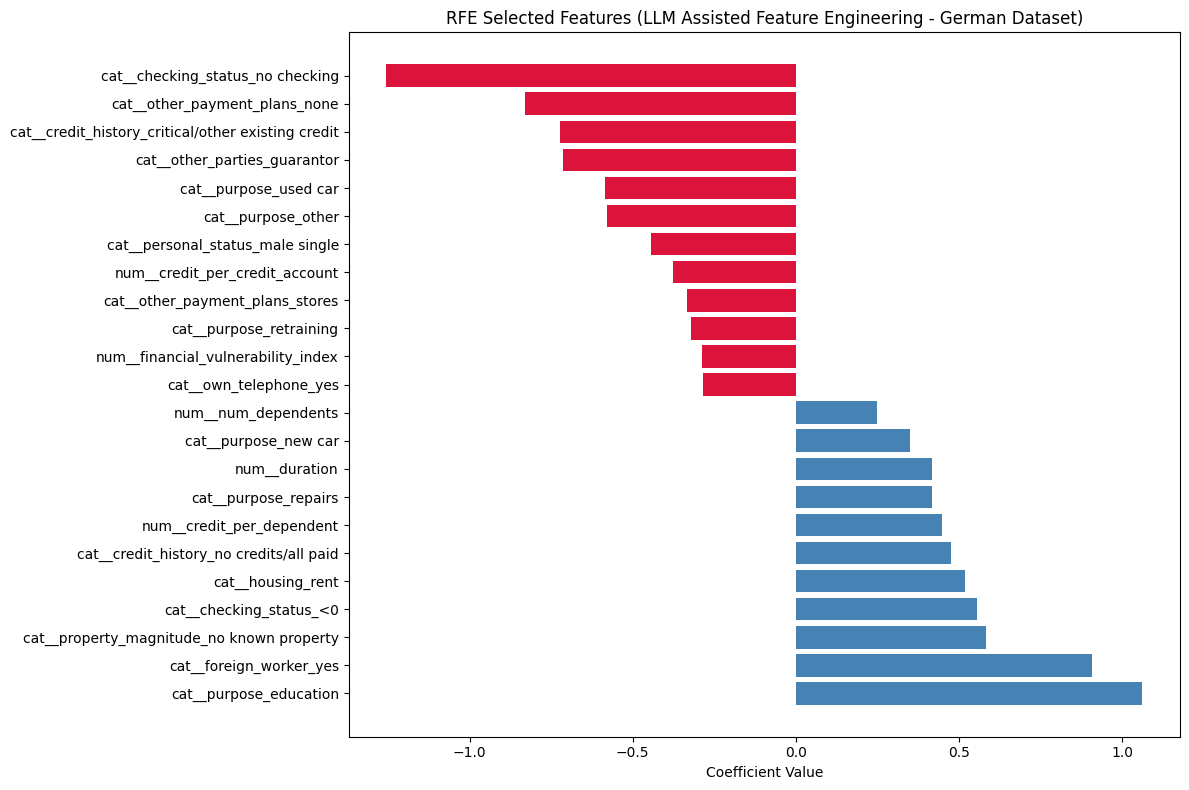

In [32]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#4682B4' if c > 0 else '#DC143C' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (LLM Assisted Feature Engineering - German Dataset)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.001,
        max_iter=1000,
        solver='liblinear',
        penalty='l2',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Logistic Regression", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[159  51]
 [ 27  63]]
classification_report:
               precision    recall  f1-score   support

           0       0.85      0.76      0.80       210
           1       0.55      0.70      0.62        90

    accuracy                           0.74       300
   macro avg       0.70      0.73      0.71       300
weighted avg       0.76      0.74      0.75       300

Model                   Logistic Regression
Method                                SMOTE
PR-AUC                             0.581766
ROC-AUC                            0.779206
Recall (Fraud)                          0.7
Precision (Fraud)                  0.552632
F1-Score                           0.617647
True Positives (TP)                      63
False Negatives (FN)                     27
dtype: object


In [34]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
7                             cat__checking_status_<0     0.064757
2                           num__credit_per_dependent     0.036535
3                      num__credit_per_credit_account     0.030056
5                              num__age_burden_factor     0.025163
20                                  cat__housing_rent     0.021548
22                            cat__foreign_worker_yes     0.014340
12                             cat__purpose_education     0.012729
13                               cat__purpose_new car     0.012243
11            cat__credit_history_no credits/all paid     0.010625
1                                 num__num_dependents     0.004663
14                            cat__purpose_retraining    -0.000413
19                    cat__other_payment_plans_stores    -0.000495
8                          cat__checking_status_>=200    -0.005048
17                       cat__other_parties_guarantor    -0.00

RF - CW

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=10,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Random Forest","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[177  33]
 [ 46  44]]
classification_report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.82       210
           1       0.57      0.49      0.53        90

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300

Model                   Random Forest
Method                  Class Weights
PR-AUC                       0.605949
ROC-AUC                      0.779894
Recall (Fraud)               0.488889
Precision (Fraud)            0.571429
F1-Score                     0.526946
True Positives (TP)                44
False Negatives (FN)               46
dtype: object


In [36]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 14 out of 47 features.
num__credit_pressure_ratio          0.097266
num__unsecured_exposure_gap         0.095571
num__credit_per_month               0.087485
cat__checking_status_no checking    0.083842
num__credit_per_credit_account      0.083468
num__credit_per_dependent           0.082553
num__credit_amount                  0.082267
num__liquidity_ratio                0.079654
num__age_burden_factor              0.066775
num__duration                       0.060680
dtype: float64


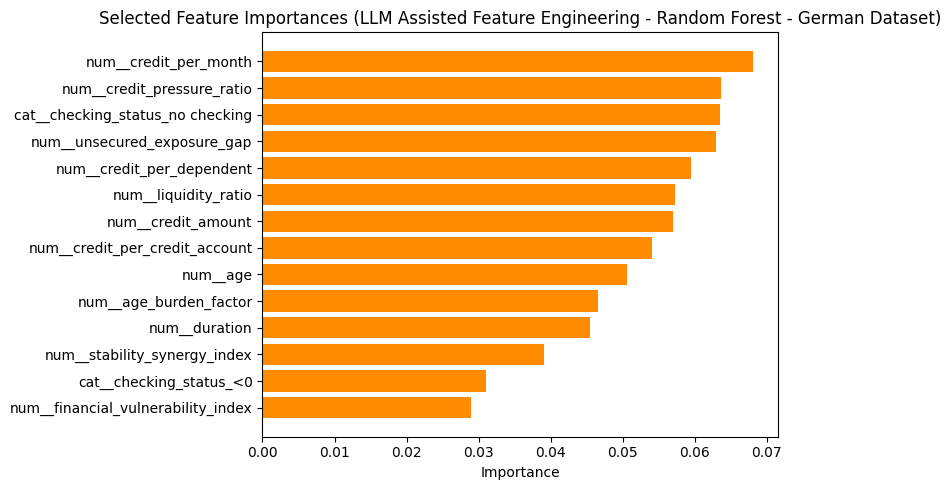

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#FF8C00'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - Random Forest - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [38]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_features='log2',
        max_depth=20,
        criterion='entropy',
        n_jobs=-1,
        class_weight=None
    ))
]) 

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Random Forest","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[174  36]
 [ 39  51]]
classification_report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       210
           1       0.59      0.57      0.58        90

    accuracy                           0.75       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.75      0.75      0.75       300

Model                   Random Forest
Method                          SMOTE
PR-AUC                       0.573813
ROC-AUC                      0.785529
Recall (Fraud)               0.566667
Precision (Fraud)            0.586207
F1-Score                     0.576271
True Positives (TP)                51
False Negatives (FN)               39
dtype: object


In [39]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 18 out of 47 features.
cat__checking_status_no checking    0.106297
num__unsecured_exposure_gap         0.073311
num__credit_per_month               0.067949
num__liquidity_ratio                0.067309
num__credit_pressure_ratio          0.067108
cat__checking_status_<0             0.066779
num__duration                       0.064379
num__credit_per_credit_account      0.059152
num__credit_amount                  0.058851
num__credit_per_dependent           0.056932
dtype: float64


XGB - CW

In [40]:
!pip install xgboost

In [41]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1] 
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGBoost","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[169  41]
 [ 36  54]]
classification_report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       210
           1       0.57      0.60      0.58        90

    accuracy                           0.74       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.75      0.74      0.75       300

Model                         XGBoost
Method                  Class Weights
PR-AUC                       0.604642
ROC-AUC                          0.78
Recall (Fraud)                    0.6
Precision (Fraud)            0.568421
F1-Score                     0.583784
True Positives (TP)                54
False Negatives (FN)               36
dtype: object


In [42]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 24 out of 47
cat__checking_status_no checking                      0.223462
cat__purpose_radio/tv                                 0.072233
cat__property_magnitude_no known property             0.060248
cat__other_payment_plans_none                         0.052506
cat__purpose_education                                0.045513
cat__credit_history_critical/other existing credit    0.044587
num__duration                                         0.035609
cat__purpose_used car                                 0.035550
cat__property_magnitude_real estate                   0.033838
num__tenure_weighted_housing_risk                     0.033529
dtype: float32


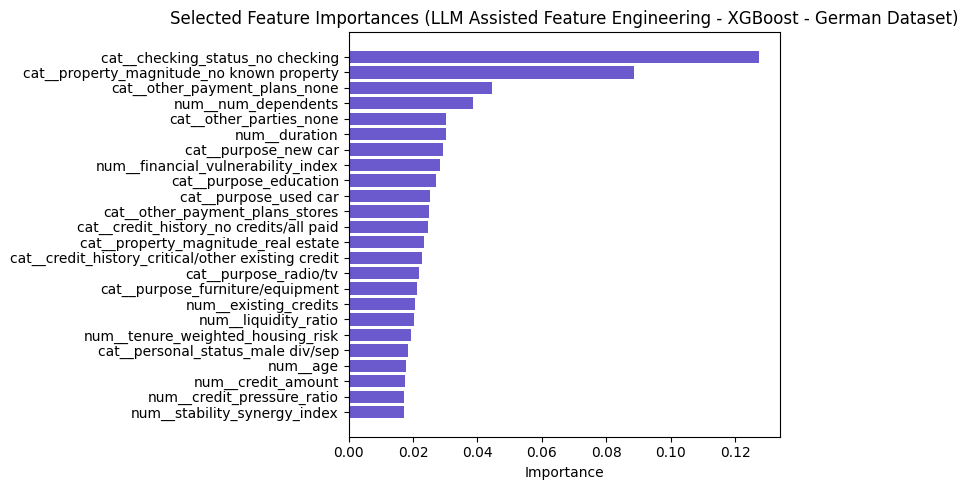

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#6A5ACD'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - XGBoost - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [44]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[181  29]
 [ 35  55]]
classification_report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       210
           1       0.65      0.61      0.63        90

    accuracy                           0.79       300
   macro avg       0.75      0.74      0.74       300
weighted avg       0.78      0.79      0.78       300

Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.626844
ROC-AUC                 0.801376
Recall (Fraud)          0.611111
Precision (Fraud)       0.654762
F1-Score                0.632184
True Positives (TP)           55
False Negatives (FN)          35
dtype: object


In [45]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 24 out of 47
cat__checking_status_no checking                      0.242265
cat__credit_history_critical/other existing credit    0.094597
cat__checking_status_<0                               0.060016
cat__property_magnitude_real estate                   0.055174
cat__purpose_new car                                  0.048273
cat__housing_rent                                     0.043455
cat__personal_status_male single                      0.043121
cat__checking_status_>=200                            0.037209
cat__purpose_education                                0.035517
cat__other_payment_plans_none                         0.033645
dtype: float32


In [57]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

                 Model         Method    PR-AUC   ROC-AUC  Recall (Fraud)  \
0  Logistic Regression  Class Weights  0.624451  0.773122        0.744444   
1  Logistic Regression          SMOTE  0.581766  0.779206        0.700000   
2        Random Forest  Class Weights  0.605949  0.779894        0.488889   
3        Random Forest          SMOTE  0.573813  0.785529        0.566667   
4              XGBoost  Class Weights  0.604642  0.780000        0.600000   
5              XGBoost          SMOTE  0.626844  0.801376        0.611111   

   Precision (Fraud)  F1-Score  True Positives (TP)  False Negatives (FN)  
0           0.507576  0.603604                   67                    23  
1           0.552632  0.617647                   63                    27  
2           0.571429  0.526946                   44                    46  
3           0.586207  0.576271                   51                    39  
4           0.568421  0.583784                   54                    36  
5   

Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

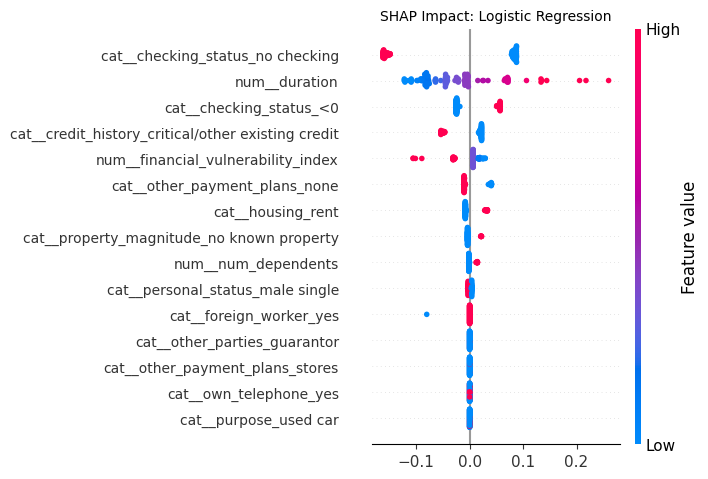

In [58]:
# --- LOGISTIC REGRESSION SHAP ---

import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

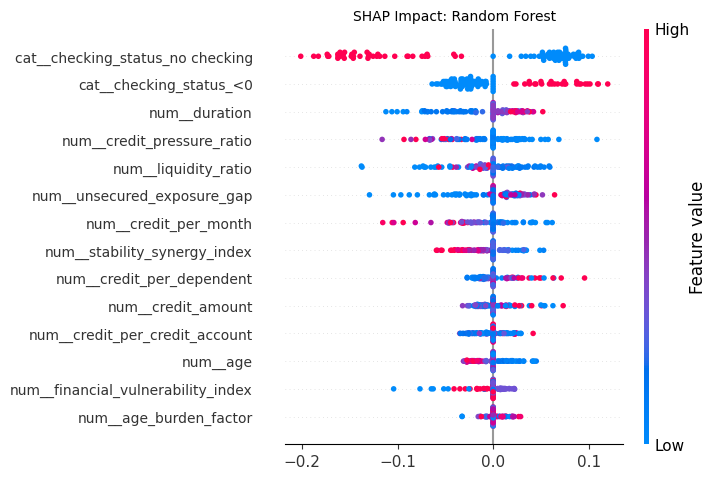

In [59]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

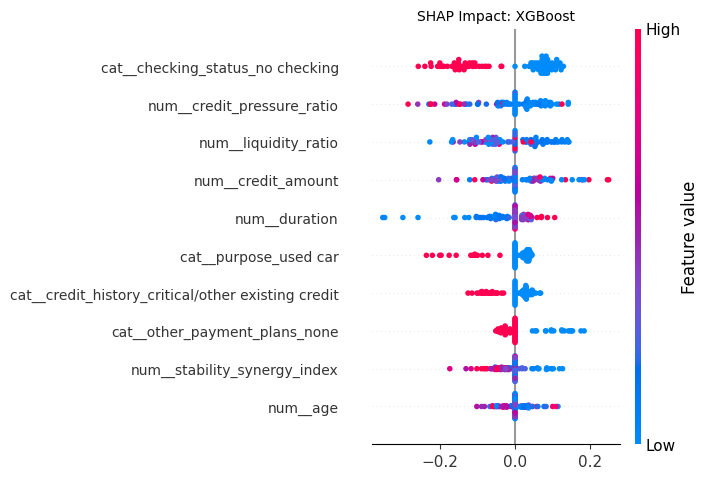

In [60]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()